# Toxic Clusters Feature Analysis

This notebook analyzes the semantic features of clusters identified in the `examine_roberta_embeddings.ipynb` notebook.

## 0. Preamble

In [1]:
import pandas as pd
import numpy as np

## 1. Load Data

In [2]:
# Load cluster assignments from the embedding analysis notebook
clusters = pd.read_csv('/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_assignments.csv')
print(f"Cluster assignments shape: {clusters.shape}")
print(f"Sources: {clusters['source'].unique()}")
clusters.head()

Cluster assignments shape: (5170, 5)
Sources: ['acl' 'coca']


,token_id,source,source_cluster,joint_cluster,embedding
0,0,acl,2,5,[ 1.88300341e-01 -6.52997242e-03 8.71063247e-...
1,1,acl,1,3,[ 3.34079146e-01 2.13974804e-01 -2.95035690e-...
2,2,acl,1,1,[ 2.41794646e-01 2.57757246e-01 -1.71810940e-...
3,3,acl,7,5,[-1.87376544e-01 1.70035422e-01 -2.37446934e-...
4,4,acl,5,2,[ 3.43040228e-02 -6.95125014e-02 1.51876926e-...


In [3]:
# Load feature data for each source
features_acl = pd.read_csv('/home/gsc685/data/features/acl/toxic_feature_vectors_roberta_binder_layer7.csv')
features_acl['source'] = 'acl'

features_coca = pd.read_csv('/home/gsc685/data/features/coca/toxic_feature_vectors_roberta_binder_layer7.csv')
features_coca['source'] = 'coca'

print(f"ACL features shape: {features_acl.shape}")
print(f"COCA features shape: {features_coca.shape}")
print(f"\nACL columns: {features_acl.columns.tolist()[:10]}...")
features_acl.head()

FileNotFoundError: [Errno 2] No such file or directory: '/home/gsc685/data/features/acl/toxic_feature_vectors_roberta_binder_layer7.csv'

In [ ]:
# Combine feature dataframes
features = pd.concat([features_acl_filtered, features_coca_filtered], ignore_index=True)
print(f"Combined features shape: {features.shape}")
features.head()

Combined features shape: (2645771, 7)


,Unnamed: 0,cluster,feature,predicted_value,source,token_id,word
0,0,3,FALSE,0.014602,acl,3339,toxic
1,1,3,TRUE,0.103651,acl,3339,toxic
2,6,3,able,-0.568581,acl,3339,toxic
3,7,3,above,0.217135,acl,3339,toxic
4,18,3,accept,0.193331,acl,3339,toxic


In [ ]:
# Join cluster assignments with features on (token_id, source)
# This ensures we match correctly since token_id is only unique within each source
df = features.merge(clusters, on=['token_id', 'source'], how='inner')

print(f"Joined dataframe shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTokens per source:")
print(df.groupby('source')['token_id'].nunique())
df.head()

Joined dataframe shape: (2645771, 10)

Columns: ['Unnamed: 0', 'cluster', 'feature', 'predicted_value', 'source', 'token_id', 'word', 'source_cluster', 'joint_cluster', 'embedding']

Tokens per source:
source
acl     948
coca    979
Name: token_id, dtype: int64


,Unnamed: 0,cluster,feature,predicted_value,source,token_id,word,source_cluster,joint_cluster,embedding
0,0,3,FALSE,0.014602,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
1,1,3,TRUE,0.103651,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
2,6,3,able,-0.568581,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
3,7,3,above,0.217135,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...
4,18,3,accept,0.193331,acl,3339,toxic,2,5,[ 2.07054377e-01 3.08322698e-01 -1.36267737e-...


## 2. Joint Clustering Regressions

For each joint cluster, run logistic regression models predicting source (COCA vs ACL) from each feature's predicted value. This identifies which semantic features best distinguish between sources within each cluster.

In [ ]:
from sklearn.linear_model import LogisticRegression
from scipy import stats

# Pivot features to wide format for regression
# Each row = one token, columns = feature values
feature_matrix = df.pivot_table(
    index=['token_id', 'source'], 
    columns='feature', 
    values='predicted_value'
).reset_index()

# Merge with cluster assignments
feature_matrix = feature_matrix.merge(
    clusters[['token_id', 'source', 'joint_cluster']], 
    on=['token_id', 'source']
)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"Joint clusters: {sorted(feature_matrix['joint_cluster'].unique())}")
print(f"\nSamples per cluster:")
print(feature_matrix['joint_cluster'].value_counts().sort_index())
feature_matrix.head()

In [ ]:
# Get feature columns (exclude metadata columns)
metadata_cols = ['token_id', 'source', 'joint_cluster']
feature_cols = [col for col in feature_matrix.columns if col not in metadata_cols]
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols[:20]}...")

In [ ]:
# Run logistic regression for each cluster and feature
# Predicting source (1=coca, 0=acl) from feature value

regression_results = []
joint_clusters = sorted(feature_matrix['joint_cluster'].unique())

for cluster in joint_clusters:
    print(f"\nAnalyzing cluster {cluster}...")
    
    # Get data for this cluster
    cluster_data = feature_matrix[feature_matrix['joint_cluster'] == cluster].copy()
    
    # Create binary target: 1 = coca, 0 = acl
    y = (cluster_data['source'] == 'coca').astype(int).values
    n_coca = y.sum()
    n_acl = len(y) - n_coca
    
    print(f"  Cluster {cluster}: n={len(y)} (ACL={n_acl}, COCA={n_coca})")
    
    # Skip if cluster has only one source
    if n_coca == 0 or n_acl == 0:
        print(f"  Skipping cluster {cluster} - only one source present")
        continue
    
    # For each feature, run logistic regression
    for feature_name in feature_cols:
        X = cluster_data[feature_name].values.reshape(-1, 1)
        
        # Skip if no variance
        if X.std() == 0:
            continue
        
        try:
            lr = LogisticRegression(random_state=42, max_iter=1000)
            lr.fit(X, y)
            
            coef = lr.coef_[0][0]
            accuracy = lr.score(X, y)
            
            regression_results.append({
                'joint_cluster': cluster,
                'feature': feature_name,
                'coefficient': coef,
                'accuracy': accuracy,
                'n_samples': len(y),
                'n_coca': n_coca,
                'n_acl': n_acl
            })
        except Exception as e:
            continue

results_df = pd.DataFrame(regression_results)
print(f"\nTotal regression results: {len(results_df)}")
results_df.head()

In [ ]:
# Show top 10 most predictive features for each cluster
# Positive coefficient = higher feature value predicts COCA
# Negative coefficient = higher feature value predicts ACL

print("=" * 80)
print("TOP 10 FEATURES PREDICTING SOURCE FOR EACH JOINT CLUSTER")
print("(Positive coef = predicts COCA, Negative coef = predicts ACL)")
print("=" * 80)

for cluster in joint_clusters:
    cluster_results = results_df[results_df['joint_cluster'] == cluster].copy()
    
    if len(cluster_results) == 0:
        print(f"\nCluster {cluster}: No results (single source)")
        continue
    
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_features = cluster_results.nlargest(10, 'abs_coef')
    
    n_samples = top_features.iloc[0]['n_samples']
    n_coca = top_features.iloc[0]['n_coca']
    n_acl = top_features.iloc[0]['n_acl']
    
    print(f"\nCluster {cluster} (n={n_samples}, ACL={n_acl}, COCA={n_coca}):")
    print(top_features[['feature', 'coefficient', 'accuracy']].to_string(index=False))

In [ ]:
# Save regression results
output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_joint_cluster_regression_results.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

In [ ]:
# Visualization: Top features by cluster
import matplotlib.pyplot as plt

# Only plot clusters with both sources
clusters_with_both = results_df['joint_cluster'].unique()

fig, axes = plt.subplots(len(clusters_with_both), 1, figsize=(12, 4*len(clusters_with_both)))

if len(clusters_with_both) == 1:
    axes = [axes]

for idx, cluster in enumerate(sorted(clusters_with_both)):
    ax = axes[idx]
    
    cluster_results = results_df[results_df['joint_cluster'] == cluster].copy()
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_15 = cluster_results.nlargest(15, 'abs_coef')
    
    colors = ['coral' if c > 0 else 'steelblue' for c in top_15['coefficient']]
    ax.barh(range(len(top_15)), top_15['coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['feature'])
    ax.set_xlabel('Coefficient (+ = COCA, - = ACL)')
    ax.set_title(f'Joint Cluster {cluster} (ACL={int(top_15.iloc[0]["n_acl"])}, COCA={int(top_15.iloc[0]["n_coca"])})')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_joint_cluster_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved.")

## 3. Cluster vs All Others Regressions

For each joint cluster, run logistic regression models predicting cluster membership (this cluster vs all other clusters) from each feature's predicted value. This identifies which semantic features best distinguish each cluster from the rest, regardless of source.

In [ ]:
# Run logistic regression for each cluster vs all others
# Predicting cluster membership (1=in cluster, 0=not in cluster) from feature value

cluster_vs_all_results = []
joint_clusters = sorted(feature_matrix['joint_cluster'].unique())

for cluster in joint_clusters:
    print(f"\nAnalyzing cluster {cluster} vs all others...")
    
    # Create binary target: 1 = in this cluster, 0 = in any other cluster
    y = (feature_matrix['joint_cluster'] == cluster).astype(int).values
    n_in_cluster = y.sum()
    n_other = len(y) - n_in_cluster
    
    print(f"  Cluster {cluster}: n_in={n_in_cluster}, n_other={n_other}")
    
    # For each feature, run logistic regression
    for feature_name in feature_cols:
        X = feature_matrix[feature_name].values.reshape(-1, 1)
        
        # Skip if no variance
        if X.std() == 0:
            continue
        
        try:
            lr = LogisticRegression(random_state=42, max_iter=1000)
            lr.fit(X, y)
            
            coef = lr.coef_[0][0]
            accuracy = lr.score(X, y)
            
            cluster_vs_all_results.append({
                'joint_cluster': cluster,
                'feature': feature_name,
                'coefficient': coef,
                'accuracy': accuracy,
                'n_in_cluster': n_in_cluster,
                'n_other': n_other,
                'n_total': len(y)
            })
        except Exception as e:
            continue

cluster_vs_all_df = pd.DataFrame(cluster_vs_all_results)
print(f"\nTotal regression results: {len(cluster_vs_all_df)}")
cluster_vs_all_df.head()


Analyzing cluster 0 vs all others...
  Cluster 0: n_in=265, n_other=1662

Analyzing cluster 1 vs all others...
  Cluster 1: n_in=172, n_other=1755

Analyzing cluster 2 vs all others...
  Cluster 2: n_in=142, n_other=1785

Analyzing cluster 3 vs all others...
  Cluster 3: n_in=305, n_other=1622

Analyzing cluster 4 vs all others...
  Cluster 4: n_in=100, n_other=1827

Analyzing cluster 5 vs all others...
  Cluster 5: n_in=561, n_other=1366

Analyzing cluster 6 vs all others...
  Cluster 6: n_in=181, n_other=1746

Analyzing cluster 7 vs all others...
  Cluster 7: n_in=79, n_other=1848

Analyzing cluster 8 vs all others...
  Cluster 8: n_in=122, n_other=1805

Total regression results: 12357


,joint_cluster,feature,coefficient,accuracy,n_in_cluster,n_other,n_total
0,0,FALSE,0.535760,0.862481,265,1662,1927
1,0,TRUE,0.541483,0.862481,265,1662,1927
2,0,able,0.880024,0.862481,265,1662,1927
3,0,above,0.479058,0.862481,265,1662,1927
4,0,accept,0.867920,0.862481,265,1662,1927


In [ ]:
# Show top 10 most predictive features for each cluster vs all others
# Positive coefficient = higher feature value predicts membership in this cluster
# Negative coefficient = higher feature value predicts membership in other clusters

print("=" * 80)
print("TOP 10 FEATURES PREDICTING CLUSTER MEMBERSHIP (vs ALL OTHER CLUSTERS)")
print("(Positive coef = predicts THIS cluster, Negative coef = predicts OTHER clusters)")
print("=" * 80)

for cluster in joint_clusters:
    cluster_results = cluster_vs_all_df[cluster_vs_all_df['joint_cluster'] == cluster].copy()
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_features = cluster_results.nlargest(10, 'abs_coef')
    
    n_in = top_features.iloc[0]['n_in_cluster']
    n_other = top_features.iloc[0]['n_other']
    
    print(f"\nCluster {cluster} (n={n_in}) vs Others (n={n_other}):")
    print(top_features[['feature', 'coefficient', 'accuracy']].to_string(index=False))

TOP 10 FEATURES PREDICTING CLUSTER MEMBERSHIP (vs ALL OTHER CLUSTERS)
(Positive coef = predicts THIS cluster, Negative coef = predicts OTHER clusters)

Cluster 0 (n=265) vs Others (n=1662):
 feature  coefficient  accuracy
  origin    -6.157596  0.862481
document    -5.882619  0.862481
 finance     4.997331  0.861443
    deal     4.310555  0.862481
   fresh    -4.243410  0.862481
   adult     3.883264  0.862481
  theory    -3.784653  0.862481
   grave    -3.588137  0.861962
     ink    -3.403978  0.862481
  regret     3.402677  0.864556

Cluster 1 (n=172) vs Others (n=1755):
 feature  coefficient  accuracy
    rope     5.461710  0.910223
continue    -4.983219  0.910742
schedule    -4.373771  0.910742
   stalk     4.356522  0.910742
    comb    -4.043272  0.910223
   crisp    -3.942937  0.910742
   rhyme     3.889548  0.910742
   guard     3.877260  0.910742
     pit     3.473864  0.910742
   swamp     3.461600  0.910742

Cluster 2 (n=142) vs Others (n=1785):
  feature  coefficient  accu

In [ ]:
# Save cluster vs all results
output_path = '/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_vs_all_regression_results.csv'
cluster_vs_all_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

Results saved to: /home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_vs_all_regression_results.csv


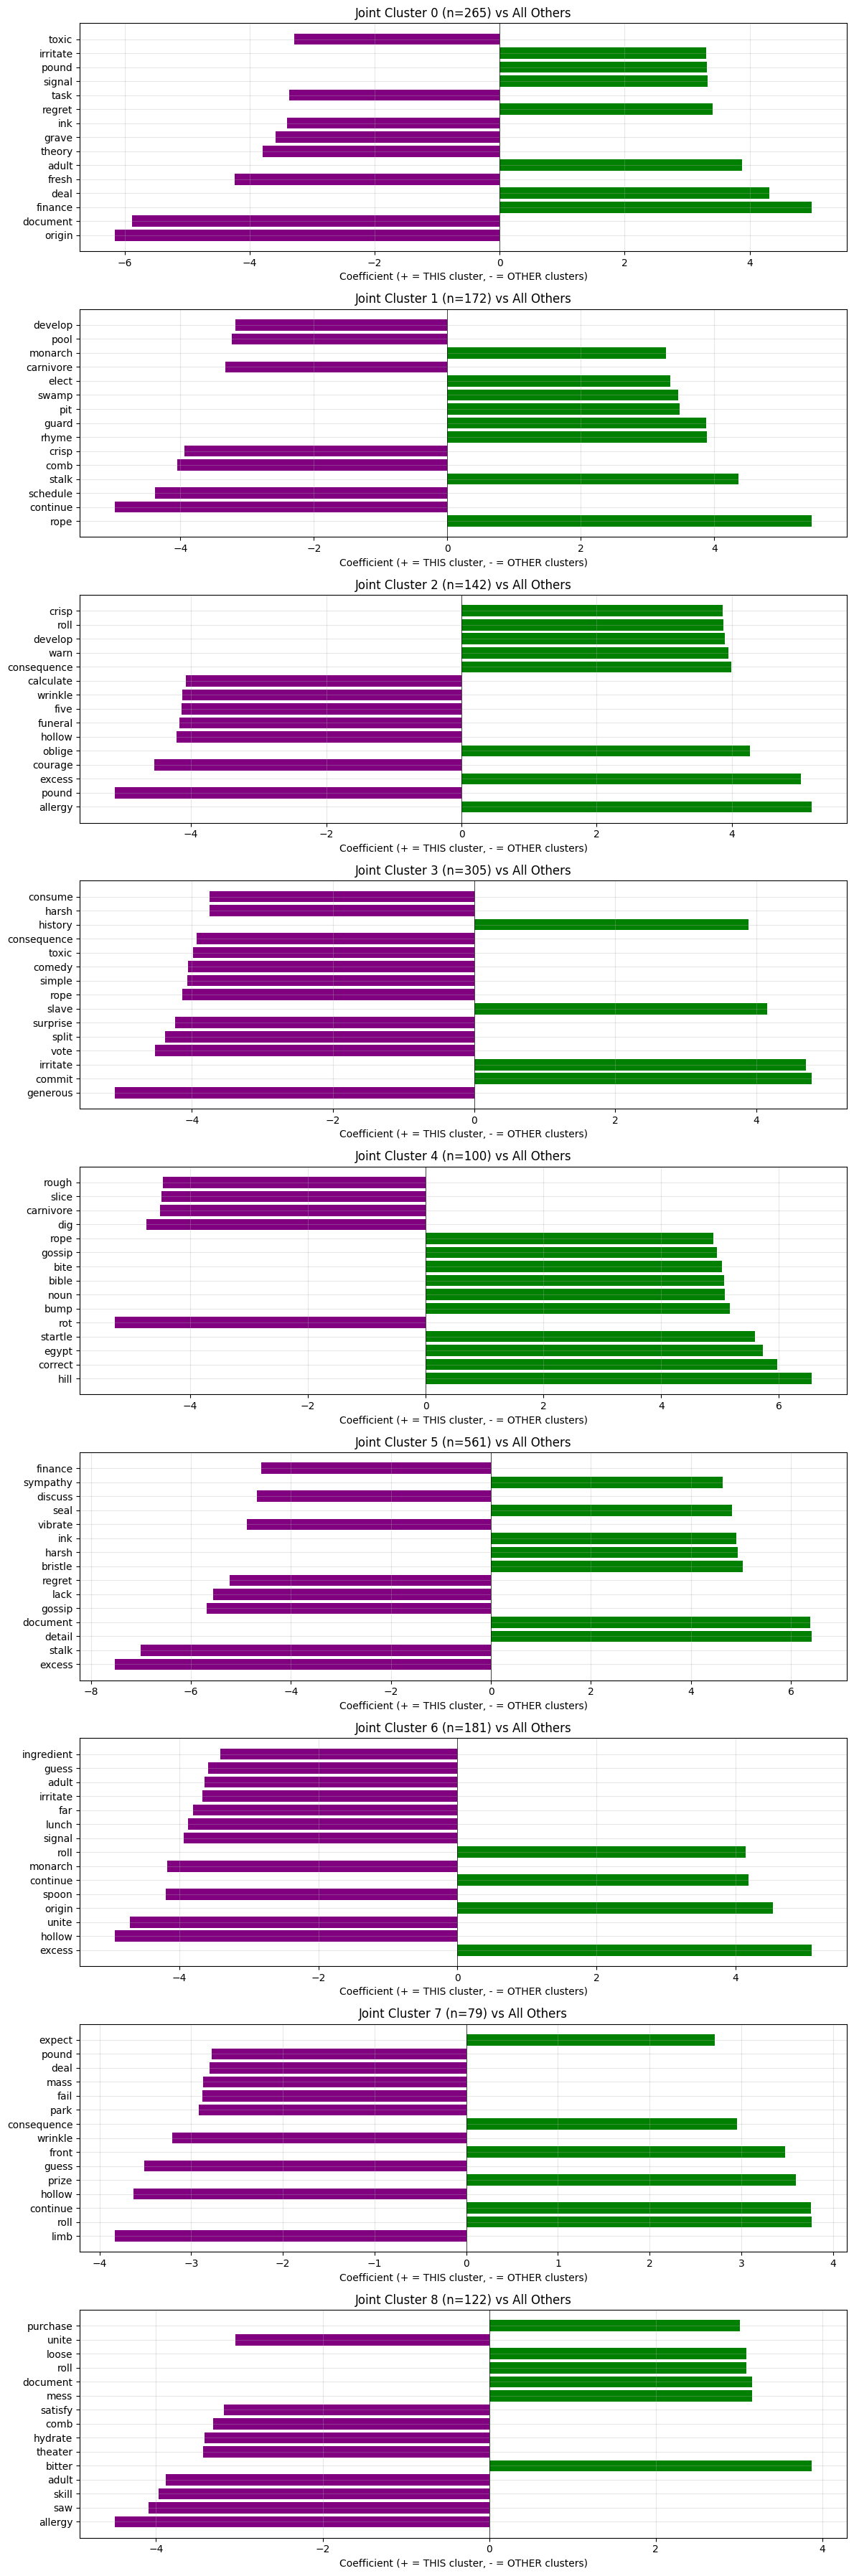

Visualization saved.


In [ ]:
# Visualization: Top features for each cluster vs all others
fig, axes = plt.subplots(len(joint_clusters), 1, figsize=(12, 4*len(joint_clusters)))

if len(joint_clusters) == 1:
    axes = [axes]

for idx, cluster in enumerate(joint_clusters):
    ax = axes[idx]
    
    cluster_results = cluster_vs_all_df[cluster_vs_all_df['joint_cluster'] == cluster].copy()
    cluster_results['abs_coef'] = cluster_results['coefficient'].abs()
    top_15 = cluster_results.nlargest(15, 'abs_coef')
    
    colors = ['green' if c > 0 else 'purple' for c in top_15['coefficient']]
    ax.barh(range(len(top_15)), top_15['coefficient'], color=colors)
    ax.set_yticks(range(len(top_15)))
    ax.set_yticklabels(top_15['feature'])
    ax.set_xlabel('Coefficient (+ = THIS cluster, - = OTHER clusters)')
    ax.set_title(f'Joint Cluster {cluster} (n={int(top_15.iloc[0]["n_in_cluster"])}) vs All Others')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/gsc685/acl_metapragmatics/toxic_exploratory_analysis/toxic_cluster_vs_all_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved.")

In [ ]:
# Load original sentence data to display sample sentences per cluster
acl_tokens = pd.read_csv('/home/gsc685/data/collected_tokens/acl/toxic.csv')
acl_tokens['source'] = 'acl'
acl_tokens = acl_tokens.rename(columns={acl_tokens.columns[0]: 'token_id'})

coca_tokens = pd.read_csv('/home/gsc685/data/collected_tokens/coca/toxic.csv')
coca_tokens['source'] = 'coca'
coca_tokens = coca_tokens.rename(columns={coca_tokens.columns[0]: 'token_id'})

tokens = pd.concat([acl_tokens, coca_tokens], ignore_index=True)

# Merge with cluster assignments
tokens_with_clusters = tokens.merge(clusters[['token_id', 'source', 'joint_cluster']], on=['token_id', 'source'])

print(f"Tokens with clusters: {len(tokens_with_clusters)}")
tokens_with_clusters.head()

In [ ]:
# Sample sentences from each joint cluster
print("=" * 80)
print("SAMPLE SENTENCES FROM EACH JOINT CLUSTER")
print("=" * 80)

for cluster in sorted(tokens_with_clusters['joint_cluster'].unique()):
    cluster_data = tokens_with_clusters[tokens_with_clusters['joint_cluster'] == cluster]
    n_acl = (cluster_data['source'] == 'acl').sum()
    n_coca = (cluster_data['source'] == 'coca').sum()
    
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster} (n={len(cluster_data)}, ACL={n_acl}, COCA={n_coca})")
    print(f"{'='*80}")
    
    # Sample 5 sentences (or fewer if cluster is smaller)
    sample = cluster_data.sample(n=min(5, len(cluster_data)), random_state=42)
    
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        source = row['source'].upper()
        sentence = row['sentence'][:200] + '...' if len(row['sentence']) > 200 else row['sentence']
        print(f"\n  [{source}] {sentence}")

SAMPLE SENTENCES FROM EACH JOINT CLUSTER

CLUSTER 0 (n=567, ACL=372, COCA=195)

  [COCA] That 's a primary takeaway of the research on poverty : part of what makes poverty toxic may be the lack of control over what 's happening to you . #

  [COCA] @!KIRSTEN-GILLIBRAND# And you just heard from these victims , there are too many command climates that are toxic .

  [ACL] Online abuse can inflict harm on users and communities, making online spaces unsafe and toxic.

  [COCA] And it truly is , you know , it 's ... @!MIKE-MYERS# It 's a toxic - I would say it 's the industrial disease of creativity .

  [COCA] The moves this past week may not simplify Matheny 's call but so far it 's turned parts of the bullpen from toxic to electric .

CLUSTER 1 (n=735, ACL=717, COCA=18)

  [ACL] The main contributions of this work are the following: • We addressed for the second time the task of unsupervised civil rephrases of toxic texts, relying for the first time on the Civil Comments data...

  [ACL]